# Neural Networks Project: Drowsiness Detection

## Importing necessary libraries

In [ ]:
### **Importing necessary libraries**

In [2]:
import numpy as np
import pandas as pd 
import os
import cv2
import matplotlib.pyplot as plt

# Use a transfer-learning friendly resolution for MobileNetV2.
IMG_SIZE = 160

## Getting labels for the train dataset

In [3]:
labels = os.listdir("train")
labels

['Closed', 'no_yawn', 'Open', 'yawn']

### Example Image: Eyes closed because it is a sign of drowsiness

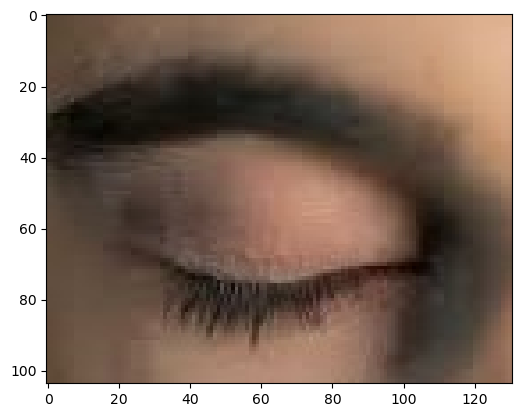

In [4]:
plt.imshow(plt.imread("train/Closed/_26.jpg"))

###  Plotting an image with mouth open because yawning is also a sign of drowsiness

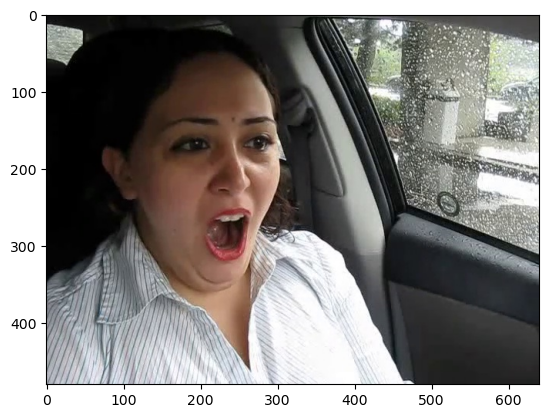

In [5]:
plt.imshow(plt.imread("train/yawn/109.jpg"))  # display the first image in the yawn_no_yawn list

## Preprocessing Images
### Yawning Dataset: Resizing + Crop Faces + Yawning Label

In [6]:
def mouth_box_from_face_xywh(x, y, w, h):
    # Heuristic mouth region from a detected face box.
    mx = x + int(0.18 * w)
    my = y + int(0.58 * h)
    mw = int(0.64 * w)
    mh = int(0.34 * h)
    return (mx, my, mw, mh)

def face_for_yawn(
    direc="train",
    face_cas_path=cv2.data.haarcascades + "haarcascade_frontalface_default.xml",
    use_mouth_crop=True,
    drop_no_face=True,
):
    yaw_no = []  # [image, class_id]
    categories = ["yawn", "no_yawn"]
    face_cascade = cv2.CascadeClassifier(face_cas_path)

    stats = {
        "total_images": 0,
        "used_samples": 0,
        "no_face": 0,
        "bad_mouth_crop": 0,
        "yawn_used": 0,
        "no_yawn_used": 0,
    }

    for category in categories:
        path_link = os.path.join(direc, category)
        class_num1 = categories.index(category)
        print(class_num1)
        for image in os.listdir(path_link):
            stats["total_images"] += 1
            image_array = cv2.imread(os.path.join(path_link, image), cv2.IMREAD_COLOR)
            if image_array is None:
                continue

            gray = cv2.cvtColor(image_array, cv2.COLOR_BGR2GRAY)
            faces = face_cascade.detectMultiScale(
                gray,
                scaleFactor=1.2,
                minNeighbors=6,
                minSize=(60, 60),
            )

            if len(faces) == 0:
                stats["no_face"] += 1
                if drop_no_face:
                    continue
                resized_array = cv2.resize(image_array, (IMG_SIZE, IMG_SIZE))
                yaw_no.append([resized_array, class_num1])
                stats["used_samples"] += 1
                stats[f"{category}_used"] += 1
                continue

            # Keep one face per image (largest) to reduce duplicate near-identical samples.
            x, y, w, h = max(faces, key=lambda f: f[2] * f[3])

            if use_mouth_crop:
                mx, my, mw, mh = mouth_box_from_face_xywh(x, y, w, h)
                roi_color = image_array[my:my+mh, mx:mx+mw]
                if roi_color is None or roi_color.size == 0:
                    stats["bad_mouth_crop"] += 1
                    continue
            else:
                roi_color = image_array[y:y+h, x:x+w]

            resized_array = cv2.resize(roi_color, (IMG_SIZE, IMG_SIZE))
            yaw_no.append([resized_array, class_num1])
            stats["used_samples"] += 1
            stats[f"{category}_used"] += 1

    return yaw_no, stats

yawn_no_yawn, yawn_stats = face_for_yawn(use_mouth_crop=True, drop_no_face=True)
count = yawn_stats["no_face"]
fallback_rate = 100.0 * count / max(1, yawn_stats["total_images"])
print(
    "No-face images:", count,
    "Total images:", yawn_stats["total_images"],
    f"Fallback rate: {fallback_rate:.2f}%",
)
print(
    "Used yawn/no_yawn samples:", yawn_stats["used_samples"],
    "(yawn:", yawn_stats["yawn_used"], ", no_yawn:", yawn_stats["no_yawn_used"], ")",
)

0
1
No-face images: 915 Total images: 1448 Fallback rate: 63.19%
Used yawn/no_yawn samples: 533 (yawn: 280 , no_yawn: 253 )


### Eyes Dataset: Resizing Images + Eyes Label

In [7]:
# This function is getting data from a directory
# It is resizing the images to a specified size and appending the resized image and its label to a list
# The function returns the list of data
def get_data(dir_path="train/"):
    # Define the labels for the data
    labels = ['Closed', 'Open']
    # Create an empty list to store the data
    data = []
    # Loop through each label in the labels list
    for label in labels:
        # Define the path to the label's directory
        path = os.path.join(dir_path, label)
        # Get the index of the label in the labels list
        class_num = labels.index(label)
        # Add 2 to the class number to account for the additional classes for face and eyes
        class_num += 2
        # Loop through each image in the label's directory
        for img in os.listdir(path):
            try:
                # Read in the image and resize it
                img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_COLOR)
                if img_array is None:
                    continue
                resized_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
                # Append the resized image and its label to the data list
                data.append([resized_array, class_num])
            except Exception as e:
                print(e)
    # Return the list of data
    return data
data_train = get_data()

### Checking the shape of data

In [8]:
data_train[0][0].shape

(160, 160, 3)

### Preprocessed Data Combination

In [9]:
def append_data():
    # Build yawn/no_yawn with mouth-focused preprocessing.
    yaw_no, yawn_stats = face_for_yawn(use_mouth_crop=True, drop_no_face=True)
    
    # Build Closed/Open eye samples.
    data = get_data()
    
    # Merge both datasets for 4-class training.
    yaw_no.extend(data)
    
    # convert the resulting list to a NumPy array and return it
    return (yaw_no, yawn_stats)

new_data, yawn_stats = append_data()
print(
    "Combined dataset size:", len(new_data),
    "| yawn/no_yawn used:", yawn_stats["used_samples"],
    "| no-face dropped:", yawn_stats["no_face"],
)

0
1
Combined dataset size: 1985 | yawn/no_yawn used: 533 | no-face dropped: 915


### Transforming Appended Dataset and Splitting Features

In [10]:
# Initialize empty lists to store features and labels
X = []
y = []

# Iterate over each tuple of feature and label in the new_data list
for feature, label in new_data:
    
    # Append the feature to the X list
    X.append(feature)
    
    # Append the label to the y list
    y.append(label)
# Features
X = np.array(X, dtype=np.float32)
X = X.reshape(-1, IMG_SIZE, IMG_SIZE, 3)

### One-hot Encoding the Labels (possible classes 0,1,2,3) using Label Binarizer

In [11]:
import sys
# 1. Completely remove any existing traces of sklearn
!{sys.executable} -m pip uninstall -y scikit-learn sklearn

# 2. Reinstall a fresh copy of scikit-learn
!{sys.executable} -m pip install scikit-learn

# 3. Ensure mediapipe is also installed in this specific environment
!{sys.executable} -m pip install mediapipe


Found existing installation: scikit-learn 1.6.1
Uninstalling scikit-learn-1.6.1:
  Successfully uninstalled scikit-learn-1.6.1


  Using cached scikit_learn-1.6.1-cp39-cp39-win_amd64.whl.metadata (15 kB)
Using cached scikit_learn-1.6.1-cp39-cp39-win_amd64.whl (11.2 MB)


  Using cached jax-0.4.30-py3-none-any.whl.metadata (22 kB)
  Using cached opencv_contrib_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached jaxlib-0.4.30-cp39-cp39-win_amd64.whl.metadata (1.1 kB)
  Using cached ml_dtypes-0.5.4-cp39-cp39-win_amd64.whl.metadata (9.2 kB)
  Using cached pyparsing-3.0.9-py3-none-any.whl.metadata (4.2 kB)


ERROR: Could not install packages due to an OSError: [Errno 2] No such file or directory: 'c:\\hp\\jatin\\anaconda3\\envs\\py39\\lib\\site-packages\\packaging-25.0.dist-info\\METADATA'



In [12]:
from sklearn.preprocessing import LabelBinarizer
label_bin = LabelBinarizer()
y = label_bin.fit_transform(y)

In [13]:
# psaLabels
y = np.array(y)

### Data Splitting

In [14]:
import sys
# 1. Force a clean re-install of scikit-learn
!{sys.executable} -m pip uninstall -y scikit-learn
!{sys.executable} -m pip install scikit-learn

# 2. While we're at it, let's make sure mediapipe is actually in THIS environment
!{sys.executable} -m pip install mediapipe


Found existing installation: scikit-learn 1.6.1
Uninstalling scikit-learn-1.6.1:
  Successfully uninstalled scikit-learn-1.6.1


You can safely remove it manually.
You can safely remove it manually.
You can safely remove it manually.
You can safely remove it manually.


  Using cached scikit_learn-1.6.1-cp39-cp39-win_amd64.whl.metadata (15 kB)
Using cached scikit_learn-1.6.1-cp39-cp39-win_amd64.whl (11.2 MB)


  Using cached jax-0.4.30-py3-none-any.whl.metadata (22 kB)
  Using cached opencv_contrib_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached jaxlib-0.4.30-cp39-cp39-win_amd64.whl.metadata (1.1 kB)
  Using cached ml_dtypes-0.5.4-cp39-cp39-win_amd64.whl.metadata (9.2 kB)
  Using cached pyparsing-3.0.9-py3-none-any.whl.metadata (4.2 kB)


ERROR: Could not install packages due to an OSError: [Errno 2] No such file or directory: 'c:\\hp\\jatin\\anaconda3\\envs\\py39\\lib\\site-packages\\packaging-25.0.dist-info\\METADATA'



In [15]:
from sklearn.model_selection import train_test_split
seed = 42
test_size = 0.20
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=seed, test_size=test_size)

In [16]:
import sys
# 1. Force downgrade NumPy to the stable 1.x version
!{sys.executable} -m pip install "numpy<2"

# 2. Re-install scikit-learn and mediapipe to ensure they link to the correct NumPy
!{sys.executable} -m pip install --force-reinstall scikit-learn mediapipe


  Using cached scikit_learn-1.6.1-cp39-cp39-win_amd64.whl.metadata (15 kB)
  Using cached mediapipe-0.10.33-py3-none-win_amd64.whl.metadata (9.8 kB)
  Using cached numpy-2.0.2-cp39-cp39-win_amd64.whl.metadata (59 kB)
  Using cached scipy-1.13.1-cp39-cp39-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached absl_py-2.3.1-py3-none-any.whl.metadata (3.3 kB)
  Using cached sounddevice-0.5.5-py3-none-win_amd64.whl.metadata (1.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached opencv_contrib_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached matplotlib-3.9.4-cp39-cp39-win_amd64.whl.metadata (11 kB)
  Using cached cffi-2.0.0-cp39-cp39-win_amd64.whl.metadata (2.6 kB)
  Using cached pycparser-2.23-py3-none-any.whl.metadata (993 bytes)
  Using cached contourpy-1.3.0-cp39-cp39-win_amd64.whl.metadata (5.4 kB)

  You can safely remove it manually.
error: uninstall-no-record-file

× Cannot uninstall packaging 25.0
╰─> The package's contents are unknown: no RECORD file was found for packaging.

hint: You might be able to recover from this via: pip install --force-reinstall --no-deps packaging==25.0


In [18]:
!{sys.executable} -m pip install --ignore-installed "numpy<2" scikit-learn mediapipe packaging


  Using cached numpy-1.26.4-cp39-cp39-win_amd64.whl.metadata (61 kB)
  Using cached scikit_learn-1.6.1-cp39-cp39-win_amd64.whl.metadata (15 kB)
  Using cached mediapipe-0.10.33-py3-none-win_amd64.whl.metadata (9.8 kB)
  Using cached packaging-26.1-py3-none-any.whl.metadata (3.5 kB)
  Using cached scipy-1.13.1-cp39-cp39-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached absl_py-2.3.1-py3-none-any.whl.metadata (3.3 kB)
  Using cached sounddevice-0.5.5-py3-none-win_amd64.whl.metadata (1.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached opencv_contrib_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached matplotlib-3.9.4-cp39-cp39-win_amd64.whl.metadata (11 kB)
  Using cached cffi-2.0.0-cp39-cp39-win_amd64.whl.metadata (2.6 kB)
  Using cached pycparser-2.23-py3-none-any.whl.metadata (993 bytes)
  Usin

ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'c:\\hp\\jatin\\anaconda3\\envs\\py39\\Lib\\site-packages\\numpy\\core\\_multiarray_tests.cp39-win_amd64.pyd'
Consider using the `--user` option or check the permissions.



### Modelling: Importing Modules

In [19]:
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import confusion_matrix
import tensorflow as tf

### Data Augmentation and MobileNetV2 Preprocessing

In [20]:
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_generator = test_datagen.flow(
    X_test, y_test,
    batch_size=BATCH_SIZE,
    shuffle=False
)

## MobileNetV2 Transfer Learning (Frozen + Fine-Tuning)
### Base Model Compilation:

In [21]:
# Build MobileNetV2 base model
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

# Build classification head
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)
outputs = Dense(4, activation="softmax")(x)

model = Model(inputs, outputs)

# Stage 1 compile: train only custom head
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 160, 160, 3)]     0         
                                                                 
 mobilenetv2_1.00_160 (Funct  (None, 5, 5, 1280)       2257984   
 ional)                                                          
                                                                 
 global_average_pooling2d (G  (None, 1280)             0         
 lobalAveragePooling2D)                                          
                                                                 
 batch_normalization (BatchN  (None, 1280)             5120      
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 1280)              0         
                                                             

### Training base Model using callbacks

In [22]:
stage1_checkpoint = "best_mobilenetv2_drowsiness.keras"
stage1_callbacks = [
EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2, min_lr=1e-6),
ModelCheckpoint(stage1_checkpoint, monitor="val_loss", save_best_only=True)
]

history_stage1 = model.fit(
train_generator,
epochs=12,
validation_data=test_generator,
callbacks=stage1_callbacks,
verbose=1
)

Epoch 1/12
50/50 [==============================] - 24s 446ms/step - loss: 0.8662 - accuracy: 0.8407 - val_loss: 0.5239 - val_accuracy: 0.9446 - lr: 0.0010
Epoch 2/12
50/50 [==============================] - 20s 401ms/step - loss: 0.6793 - accuracy: 0.8948 - val_loss: 0.4868 - val_accuracy: 0.9547 - lr: 0.0010
Epoch 3/12
50/50 [==============================] - 19s 386ms/step - loss: 0.6004 - accuracy: 0.9219 - val_loss: 0.4784 - val_accuracy: 0.9496 - lr: 0.0010
Epoch 4/12
50/50 [==============================] - 19s 373ms/step - loss: 0.5766 - accuracy: 0.9301 - val_loss: 0.4543 - val_accuracy: 0.9622 - lr: 0.0010
Epoch 5/12
50/50 [==============================] - 22s 447ms/step - loss: 0.5469 - accuracy: 0.9395 - val_loss: 0.4564 - val_accuracy: 0.9597 - lr: 0.0010
Epoch 6/12
50/50 [==============================] - 18s 368ms/step - loss: 0.5208 - accuracy: 0.9559 - val_loss: 0.4506 - val_accuracy: 0.9597 - lr: 0.0010
Epoch 7/12
50/50 [==============================] - 19s 377ms/st

### Finetuning the last 40 layers of MobileNetV2

In [23]:

base_model.trainable = True
for layer in base_model.layers[:-40]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

finetune_callbacks = [
EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7),
ModelCheckpoint(stage1_checkpoint, monitor="val_loss", save_best_only=True)
]

history_finetune = model.fit(
train_generator,
epochs=15,
validation_data=test_generator,
callbacks=finetune_callbacks,
verbose=1
)

history = {"stage1": history_stage1.history, "finetune": history_finetune.history}

Epoch 1/15
50/50 [==============================] - 25s 455ms/step - loss: 0.4649 - accuracy: 0.9742 - val_loss: 0.4472 - val_accuracy: 0.9547 - lr: 1.0000e-05
Epoch 2/15
50/50 [==============================] - 18s 363ms/step - loss: 0.4692 - accuracy: 0.9704 - val_loss: 0.4496 - val_accuracy: 0.9547 - lr: 1.0000e-05
Epoch 3/15
50/50 [==============================] - 22s 447ms/step - loss: 0.4641 - accuracy: 0.9773 - val_loss: 0.4297 - val_accuracy: 0.9698 - lr: 1.0000e-05
Epoch 4/15
50/50 [==============================] - 156s 3s/step - loss: 0.4657 - accuracy: 0.9742 - val_loss: 0.4292 - val_accuracy: 0.9673 - lr: 1.0000e-05
Epoch 5/15
50/50 [==============================] - 16s 324ms/step - loss: 0.4563 - accuracy: 0.9830 - val_loss: 0.4273 - val_accuracy: 0.9622 - lr: 1.0000e-05
Epoch 6/15
50/50 [==============================] - 17s 348ms/step - loss: 0.4623 - accuracy: 0.9710 - val_loss: 0.4272 - val_accuracy: 0.9673 - lr: 1.0000e-05
Epoch 7/15
50/50 [========================

**Loading best trained model**

In [24]:
import tensorflow as tf
best_model = tf.keras.models.load_model("best_mobilenetv2_drowsiness.keras")
#test_loss, test_acc = best_model.evaluate(test_generator)

test_loss, test_acc = best_model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")

13/13 [==============================] - 3s 211ms/step - loss: 0.4143 - accuracy: 0.9748
Test Accuracy: 0.9748, Test Loss: 0.4143


**Feature extraction and reshaping**

In [25]:
import numpy as np

# Ensure generator starts at the first batch so predictions align with labels
test_generator.reset()

y_pred_probs = best_model.predict(test_generator, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

y_arr = np.array(test_generator.y)
y_true = np.argmax(y_arr, axis=1) if y_arr.ndim > 1 else y_arr.astype(int)

### Yawns and no Yawns Confusion Matrix

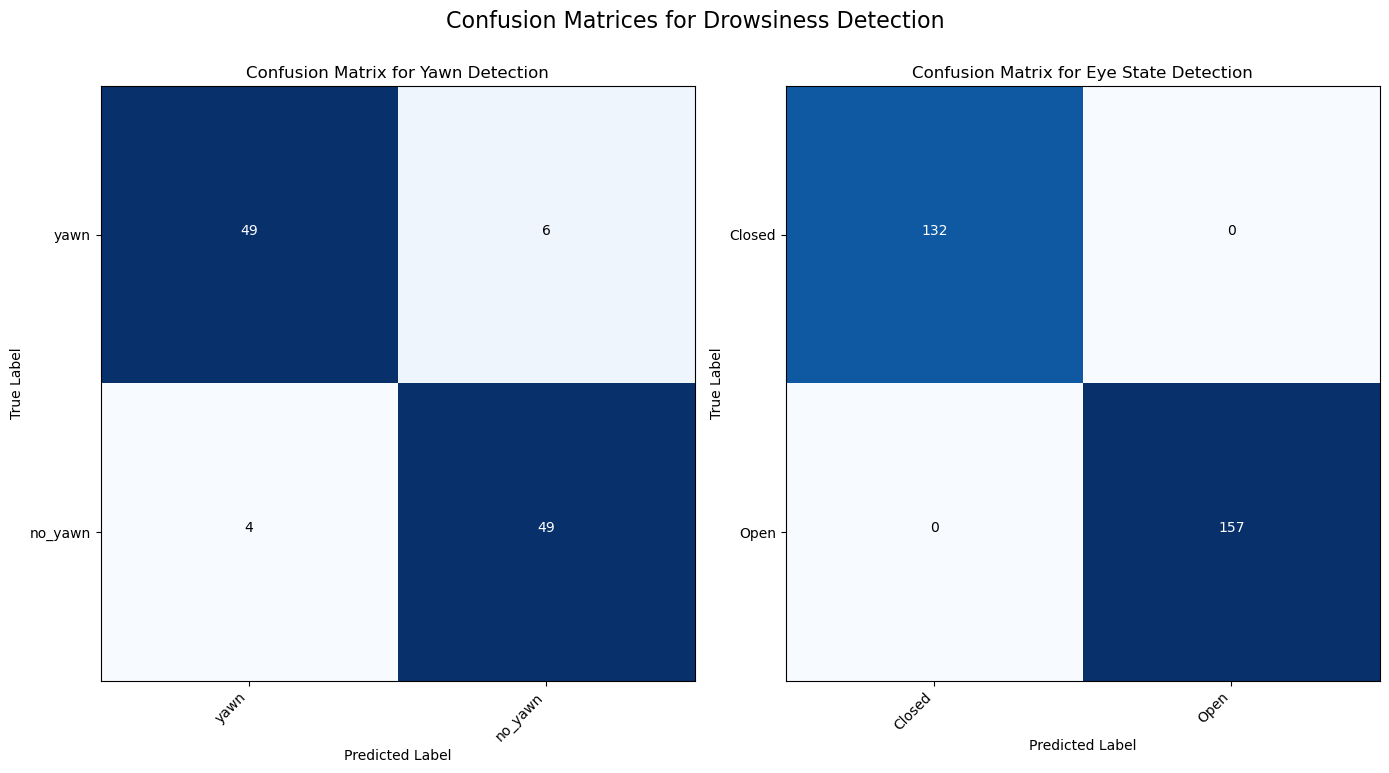

In [26]:
# Predictions for Yawns
mask_1 = (y_true == 0) | (y_true == 1)
y_true_copy = y_true[mask_1]
y_pred_copy = y_pred[mask_1]

mask_2 = (y_true == 2) | (y_true == 3)
y_true_copy_2 = y_true[mask_2]
y_pred_copy_2 = y_pred[mask_2]


cm_1 = confusion_matrix(y_true_copy, y_pred_copy)
cm_2 = confusion_matrix(y_true_copy_2, y_pred_copy_2)

# 0=yawn, 1=no_yawn, 2=Closed, 3=Open
class_names_1 = ["yawn", "no_yawn"]
class_names_2 = ["Closed", "Open"]
label_ids = list(range(len(class_names_1)))

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# --- CM 1 ---
ax = axes[0]
ax.imshow(cm_1, interpolation="nearest", cmap=plt.cm.Blues)
ax.set_title("Confusion Matrix for Yawn Detection")
ax.set_xticks(np.arange(len(class_names_1)))
ax.set_yticks(np.arange(len(class_names_1)))
ax.set_xticklabels(class_names_1, rotation=45, ha="right")
ax.set_yticklabels(class_names_1)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')

threshold = cm_1.max() / 2.0
for i in range(cm_1.shape[0]):
    for j in range(cm_1.shape[1]):
        ax.text(j, i, cm_1[i, j],
                ha="center",
                color="white" if cm_1[i, j] > threshold else "black")

# --- CM 2 ---
ax = axes[1]
ax.imshow(cm_2, interpolation="nearest", cmap=plt.cm.Blues)
ax.set_title("Confusion Matrix for Eye State Detection")
ax.set_xticks(np.arange(len(class_names_2)))
ax.set_yticks(np.arange(len(class_names_2)))
ax.set_xticklabels(class_names_2, rotation=45, ha="right")
ax.set_yticklabels(class_names_2)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')


threshold = cm_2.max() / 2.0
for i in range(cm_2.shape[0]):
    for j in range(cm_2.shape[1]):
        ax.text(j, i, cm_2[i, j],
                ha="center",
                color="white" if cm_2[i, j] > threshold else "black")

plt.tight_layout()
plt.suptitle("Confusion Matrices for Drowsiness Detection", fontsize=16)
plt.show()


## Inference Demo (Image First, Then Webcam)

In [4]:
from tensorflow.keras.models import load_model
import numpy as np
import pandas as pd
import os
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import mediapipe as mp

# 1. Configuration & Constants
IMG_SIZE = 160
CLASS_NAMES = {
    0: "yawn",
    1: "no_yawn",
    2: "eyes_closed",
    3: "eyes_open",
}

EYE_CLASS_IDS = [2, 3]
MOUTH_CLASS_IDS = [0, 1]
CONFIDENCE_THRESHOLD = 0.55

# 2. Load Model
checkpoint_path = "best_mobilenetv2_drowsiness.keras"
if os.path.exists(checkpoint_path):
    model_for_inference = load_model(checkpoint_path)
    print(f"Loaded model from {checkpoint_path}")
elif "best_model" in globals():
    model_for_inference = best_model
else:
    # Fallback to current 'model' object if defined
    model_for_inference = locals().get('model')

# 3. Initialize MediaPipe Face Detection
mp_face_detection = mp.solutions.face_detection
# model_selection=1 is optimized for faces within 5 meters
face_detector = mp_face_detection.FaceDetection(model_selection=1, min_detection_confidence=0.5)

# 4. Helper Functions
def preprocess_roi_for_model(roi_bgr, img_size=IMG_SIZE):
    if roi_bgr is None or roi_bgr.size == 0:
        return None
    # Resize to the input size the model expects
    resized = cv2.resize(roi_bgr, (img_size, img_size))
    # Convert to RGB (model was trained on RGB)
    rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB).astype(np.float32)
    # Use MobileNetV2's specific scaling (-1 to 1)
    x = preprocess_input(rgb)
    return np.expand_dims(x, axis=0)

def predict_subset(roi_bgr, allowed_ids):
    x = preprocess_roi_for_model(roi_bgr)
    if x is None:
        return "not_detected", 0.0
    
    probs = model_for_inference.predict(x, verbose=0)[0]
    
    # Filter probabilities to only include the classes we care about (eyes OR mouth)
    subset = np.array([probs[i] for i in allowed_ids], dtype=np.float32)
    subset = subset / (subset.sum() + 1e-8) # Re-normalize
    
    best_local_idx = int(np.argmax(subset))
    class_id = allowed_ids[best_local_idx]
    confidence = float(subset[best_local_idx])
    
    if confidence < CONFIDENCE_THRESHOLD:
        return "uncertain", confidence
    return CLASS_NAMES[class_id], confidence

def draw_box_with_label(image_bgr, box, label, confidence, color):
    x, y, w, h = box
    cv2.rectangle(image_bgr, (x, y), (x + w, y + h), color, 2)
    text = f"{label} ({confidence:.2f})"
    cv2.putText(image_bgr, text, (x, max(20, y - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 2, cv2.LINE_AA)

def mouth_box_from_face(face_box):
    x, y, w, h = face_box
    mx = x + int(0.18 * w)
    my = y + int(0.58 * h)
    mw = int(0.64 * w)
    mh = int(0.34 * h)
    return (mx, my, mw, mh)

# 5. Main Inference Function

import time
def detect_and_annotate_states(image_bgr):
    output = image_bgr.copy()
    h, w, _ = image_bgr.shape
    is_drowsy = False
    face_seen = False
    
    rgb_in = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    results = face_detector.process(rgb_in)

    # Return immediately if no face is detected
    if not results or not results.detections:
        return output, "not_detected", "not_detected", False

    face_seen = True
    for detection in results.detections:
        bbox = detection.location_data.relative_bounding_box
        fx, fy, fw, fh = int(bbox.xmin * w), int(bbox.ymin * h), int(bbox.width * w), int(bbox.height * h)
        fx, fy = max(0, fx), max(0, fy)
        fw, fh = min(fw, w - fx), min(fh, h - fy)
        face_box = (fx, fy, fw, fh)

        # 1. Eye Prediction (Top 45% of face)
        eye_zone_h = int(fh * 0.45)
        eye_roi = image_bgr[fy : fy + eye_zone_h, fx : fx + fw]
        eye_label, eye_conf = predict_subset(eye_roi, EYE_CLASS_IDS)
        
        # 2. Mouth Prediction
        mbox = mouth_box_from_face(face_box)
        mx, my, mw, mh = mbox
        mouth_roi = image_bgr[my : my + mh, mx : mx + mw]
        mouth_label, mouth_conf = predict_subset(mouth_roi, MOUTH_CLASS_IDS)

        # Trigger logic
        if eye_label == "eyes_closed" or mouth_label == "yawn":
            is_drowsy = True

        # Draw visual boxes
        color = (0, 0, 255) if is_drowsy else (0, 255, 0)
        cv2.rectangle(output, (fx, fy), (fx+fw, fy+fh), color, 2)
        cv2.putText(output, f"E: {eye_label} | M: {mouth_label}", (fx, fy-10), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

    return output, eye_label, mouth_label, face_seen









Loaded model from best_mobilenetv2_drowsiness.keras


### Testing model on images

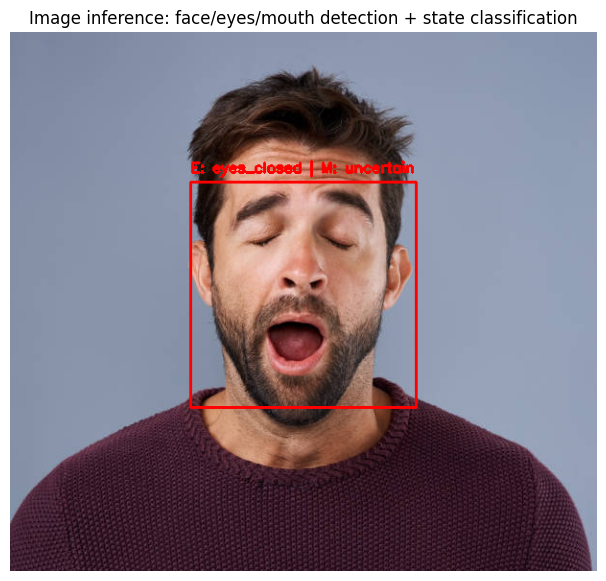

In [15]:
# IMAGE DEMO: set any local image path here and run this cell.
image_path = "test_im_2.jpg"

image_bgr = cv2.imread(image_path)
if image_bgr is None:
    raise FileNotFoundError(f"Could not read image: {image_path}")

annotated,_,_,_ = detect_and_annotate_states(image_bgr)

plt.figure(figsize=(10, 7))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Image inference: face/eyes/mouth detection + state classification")
plt.show()

In [1]:
import pygame
import time
import cv2
import os
import platform

# 1. Initialize the mixer
pygame.mixer.init()

# 2. Load your sounds
# sounds/alarm.wav = "Face alert" (when face/eyes/mouth not detected)
# sounds/alarm1.wav = Drowsiness Alert (Loud)
face_alert_sound = pygame.mixer.Sound("sounds/alarm.wav")
drowsy_loud_sound = pygame.mixer.Sound("sounds/alarm1.wav")

# 3. Set Maximum Volumes (1.0 is 100%)
drowsy_loud_sound.set_volume(1.0) 
face_alert_sound.set_volume(0.8)

# 4. Prepare specific channels to prevent one sound from cutting off the other
drowsy_channel = pygame.mixer.Channel(0)
face_channel = pygame.mixer.Channel(1)


pygame 2.6.1 (SDL 2.28.4, Python 3.10.20)
Hello from the pygame community. https://www.pygame.org/contribute.html


### Trying WEBCAM DEMO

In [2]:
import pygame
import time
import cv2
import os
import platform

# 1. Initialize the mixer
pygame.mixer.init()

# 2. Load your sounds
# sounds/alarm.wav = "Face alert" (when face/eyes/mouth not detected)
# sounds/alarm1.wav = Drowsiness Alert (Loud)
face_alert_sound = pygame.mixer.Sound("sounds/alarm.wav")
drowsy_loud_sound = pygame.mixer.Sound("sounds/alarm1.wav")

# 3. Set Maximum Volumes (1.0 is 100%)
drowsy_loud_sound.set_volume(1.0) 
face_alert_sound.set_volume(0.8)

# 4. Prepare specific channels to prevent one sound from cutting off the other
drowsy_channel = pygame.mixer.Channel(0)
face_channel = pygame.mixer.Channel(1)


In [5]:
# Logic Settings
DROWSY_TIME_LIMIT = 1.0  # 1 second of closed eyes or yawning
FACE_MISSING_LIMIT = 0.5 # 0.5 seconds of no face seen

drowsy_start_time = None
face_missing_start_time = None

cap = cv2.VideoCapture(0)
print("System Active: Monitoring for Drowsiness and Face presence...")

while True:
    ok, frame = cap.read()
    if not ok: break
    h, w, _ = frame.shape

    # Detect states using your MediaPipe + MobileNetV2 function
    annotated, eye_status, mouth_status, face_seen = detect_and_annotate_states(frame)
    current_time = time.time()

    # --- ALARM A: FACE ALERT (alarm.wav) ---
    # Trigger if face/eyes/mouth are not detected
    if not face_seen:
        if face_missing_start_time is None:
            face_missing_start_time = current_time
        
        if current_time - face_missing_start_time >= FACE_MISSING_LIMIT:
            cv2.putText(annotated, "!!! FACE ALERT: NOT DETECTED !!!", (w//6, h//2), 
                        cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 165, 255), 3)
            if not face_channel.get_busy():
                face_channel.play(face_alert_sound)
        
        drowsy_start_time = None # Reset drowsiness if we can't see the face
    else:
        face_missing_start_time = None
        face_channel.stop()

    # --- ALARM B: DROWSY ALERT (alarm1.wav) ---
    # Trigger if: (Eyes Closed) OR (Yawning) for > 1 second
    is_drowsy_state = (eye_status == "eyes_closed" or mouth_status == "yawn")

    if face_seen and is_drowsy_state:
        if drowsy_start_time is None:
            drowsy_start_time = current_time
        
        elapsed_drowsy = current_time - drowsy_start_time
        
        # Display the 1-second countdown
        warning_msg = "EYES CLOSED!" if eye_status == "eyes_closed" else "YAWNING!"
        cv2.putText(annotated, f"{warning_msg} {elapsed_drowsy:.1f}s", (10, 40), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)

        if elapsed_drowsy >= DROWSY_TIME_LIMIT:
            cv2.putText(annotated, "!!! WAKE UP !!!", (w//4, h//2 + 80), 
                        cv2.FONT_HERSHEY_SIMPLEX, 2, (0, 0, 255), 5)
            
            # Play LOUD alarm on the dedicated drowsy channel
            if not drowsy_channel.get_busy():
                drowsy_channel.play(drowsy_loud_sound)
    else:
        # Stop alarm immediately when driver is alert
        drowsy_start_time = None
        drowsy_channel.stop()

    cv2.imshow("Advanced Driver Monitoring", annotated)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
pygame.mixer.quit() # Properly shut down the mixer when quitting
cv2.destroyAllWindows()


System Active: Monitoring for Drowsiness and Face presence...


c:\Users\danie\anaconda3\envs\dl_310\lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


In [87]:
import cv2
import numpy as np

# Input video path (update as needed)
video_path = "drowsy1.mp4"  # Your video file

# Output cropped video path
output_path = "cropped_faces.mp4"

# Load cascades (reuse from your code)
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    raise RuntimeError(f"Could not open video: {video_path}")

# Get video properties
fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# Output video writer (cropped size: 160x160)
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_path, fourcc, fps, (160, 160))

print("Processing video and cropping faces...")
frame_count = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break
    
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.2, minNeighbors=5, minSize=(80, 80))
    
    if len(faces) > 0:
        # Crop the first detected face (or loop for multiple)
        x, y, w, h = faces[0]
        face_crop = frame[y:y+h, x:x+w]
        # Resize to 160x160
        resized_crop = cv2.resize(face_crop, (160, 160))
        out.write(resized_crop)
        frame_count += 1
    
    # Optional: show progress every 100 frames
    if frame_count % 100 == 0:
        print(f"Processed {frame_count} frames")

cap.release()
out.release()
print(f"Cropped video saved as {output_path} with {frame_count} frames.")

Processing video and cropping faces...
Processed 0 frames
Processed 0 frames
Processed 0 frames
Processed 0 frames
Processed 0 frames
Processed 0 frames
Processed 0 frames
Processed 0 frames
Processed 0 frames
Processed 0 frames
Processed 0 frames
Processed 0 frames
Processed 0 frames
Processed 0 frames
Processed 0 frames
Processed 0 frames
Processed 0 frames
Processed 0 frames
Processed 0 frames
Processed 0 frames
Processed 0 frames
Processed 0 frames
Processed 0 frames
Processed 0 frames
Processed 0 frames
Processed 0 frames
Processed 0 frames
Processed 0 frames
Processed 0 frames
Processed 100 frames
Cropped video saved as cropped_faces.mp4 with 144 frames.


In [38]:
# VIDEO DEMO: test model on a video file.
# Set the video path here (e.g., "train/your_video.mp4" or full path).
video_path = "drowsy1.mp4"  # Replace with your video file path

cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    raise RuntimeError(f"Could not open video: {video_path}")

print("Video started. Press 'q' to quit.")
while True:
    ok, frame = cap.read()
    if not ok:
        break

    annotated = detect_and_annotate_states(frame)
    cv2.imshow("Drowsiness Demo - Video", annotated)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()
print("Video stopped.")

Video started. Press 'q' to quit.
Video stopped.


In [39]:
import os

def process_video_folder(folder_path):
    video_files = [f for f in os.listdir(folder_path) if f.endswith(('.mp4', '.avi', '.mov', '.mkv'))]
    if not video_files:
        print(f"No video files found in {folder_path}")
        return

    print(f"Found {len(video_files)} video files. Starting playback...")
    for video_file in video_files:
        video_path = os.path.join(folder_path, video_file)
        print(f"Processing: {video_file}")

        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            print(f"Could not open video: {video_path}")
            continue

        while True:
            ok, frame = cap.read()
            if not ok:
                break

            annotated = detect_and_annotate_states(frame)
            cv2.imshow("Drowsiness Demo - Video", annotated)

            key = cv2.waitKey(1) & 0xFF
            if key == ord("q"):
                cap.release()
                cv2.destroyAllWindows()
                return  # Quit entirely
            elif key == ord("n"):
                break  # Next video

        cap.release()
        print(f"Finished {video_file}. Press 'n' for next or 'q' to quit.")

    cv2.destroyAllWindows()
    print("All videos processed.")

# Test on all videos in drowsiness.demo folder
demo_folder = "drowsiness.demo"
if os.path.exists(demo_folder):
    process_video_folder(demo_folder)
else:
    print(f"Folder {demo_folder} not found.")

Found 33 video files. Starting playback...
Processing: d_103.mp4


In [40]:
# Face detection issue solved

In [47]:
pip install pygame

   ---------------------------------------- 0.0/10.6 MB ? eta -:--:--
   -------- ------------------------------- 2.4/10.6 MB 19.1 MB/s eta 0:00:01
   ------------------- -------------------- 5.2/10.6 MB 24.5 MB/s eta 0:00:01
   ------------------------- -------------- 6.8/10.6 MB 14.0 MB/s eta 0:00:01
   ---------------------------- ----------- 7.6/10.6 MB 10.2 MB/s eta 0:00:01
   ------------------------------- -------- 8.4/10.6 MB 8.8 MB/s eta 0:00:01
   -------------------------------------- - 10.2/10.6 MB 8.7 MB/s eta 0:00:01
   ---------------------------------------- 10.6/10.6 MB 8.0 MB/s  0:00:01
Note: you may need to restart the kernel to use updated packages.


In [49]:
import pygame
pygame.mixer.init()

# This is a standard Windows system sound already on your PC:
alarm_sound = pygame.mixer.Sound("C:/Windows/Media/Alarm01.wav") 

# ... the rest of your drowsiness detection code ...


In [52]:
import cv2
import numpy as np
import pygame # For the audio alarm
import tensorflow as tf

# 1. Initialize the sound mixer
pygame.mixer.init()
# Load an alarm sound (ensure you have an 'alarm.wav' file in your folder)
# You can download any short beep/siren sound as a .wav file
alarm_sound = pygame.mixer.Sound("alarm.wav") 

# 2. Load your best model
best_model = tf.keras.models.load_model("best_mobilenetv2_drowsiness.keras")
IMG_SIZE = 160

# 3. Setup Camera
cap = cv2.VideoCapture(0)
drowsy_counter = 0
ALARM_THRESHOLD = 20 # Number of consecutive "Closed" frames to trigger alarm

while True:
    ret, frame = cap.read()
    if not ret: break

    # Preprocess the frame for MobileNetV2
    img = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0 # Normalize
    img = np.expand_dims(img, axis=0)

    # 4. Run your local model
    prediction = best_model.predict(img, verbose=0)
    
    # Assuming index 0 is 'Closed' based on your 'train' folder order
    # Adjust the index based on: labels = os.listdir("train")
    is_closed = np.argmax(prediction) == 0 

    if is_closed:
        drowsy_counter += 1
        cv2.putText(frame, f"DROWSY: {drowsy_counter}", (50, 50), 
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
    else:
        drowsy_counter = 0
        pygame.mixer.stop() # Stop alarm if eyes open

    # 5. Trigger the Local Audio Alarm
    if drowsy_counter >= ALARM_THRESHOLD:
        if not pygame.mixer.get_busy(): # Only play if not already playing
            alarm_sound.play(-1) # Loop the alarm until eyes open
        cv2.putText(frame, "!!! WAKE UP !!!", (150, 200), 
                    cv2.FONT_HERSHEY_SIMPLEX, 2, (0, 0, 255), 5)

    cv2.imshow('Drowsiness Monitor', frame)
    if cv2.waitKey(1) & 0xFF == ord('q'): break

cap.release()
cv2.destroyAllWindows()
pygame.mixer.quit()
